# Predicting Telecom Customer Churn Using Machine Learning

## Project Overview
This project applies machine learning to predict whether telecom customers are likely to churn. Two approved telecom churn datasets are used: the Iranian Churn Dataset and the Bulgarian Telecom Customer Churn Dataset.

The notebook follows the project requirements: data description, data exploration and visualization, data cleaning and preparation, classical machine learning, neural network modelling, model evaluation, findings, and preparation of outputs for the final presentation.


## 1. Importing Libraries
This section imports the libraries used for data manipulation, visualization, preprocessing, model training, neural network development, evaluation, and saving project outputs.


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Loading the Datasets
The two approved datasets are loaded from Google Drive. They are analysed separately because they come from different telecom sources and have different feature structures.


In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
import pandas as pd

iran_df = pd.read_csv('/content/drive/MyDrive/Collab Data/Customer Churn.csv')

bulg_df = pd.read_csv('/content/drive/MyDrive/Collab Data/Baza customer Telecom v2.csv')

## 3. Data Description
This section inspects the basic structure of each dataset, including the number of rows and columns, available variables, and target columns. This helps confirm that both datasets meet the project requirements and are suitable for churn prediction.


In [85]:
print("Iranian Dataset Shape:", iran_df.shape)
print("Bulgarian Dataset Shape:", bulg_df.shape)

Iranian Dataset Shape: (3150, 14)
Bulgarian Dataset Shape: (8453, 14)


In [86]:
print("Iranian Columns:")
print(iran_df.columns.tolist())

print("\nBulgarian Columns:")
print(bulg_df.columns.tolist())

Iranian Columns:
['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']

Bulgarian Columns:
['PID', 'CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP', 'KA_name', 'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs', 'AvgMobileRevenue ', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU', 'CHURN']


In [94]:
for i, col in enumerate(bulg_df.columns):
    print(i, col)

0 PID
1 CRM_PID_Value_Segment
2 EffectiveSegment
3 Billing_ZIP
4 KA_name
5 Active_subscribers
6 Not_Active_subscribers
7 Suspended_subscribers
8 Total_SUBs
9 AvgMobileRevenue 
10 AvgFIXRevenue
11 TotalRevenue
12 ARPU
13 CHURN


In [95]:
bulg_df.head().T

,0,1,2,3,4
PID,123759242,126145737,123506355,112595585,115097935
CRM_PID_Value_Segment,Bronze,Bronze,Bronze,Bronze,Iron
EffectiveSegment,SOHO,SOHO,SOHO,SOHO,SOHO
Billing_ZIP,6000.0,6400.0,6000.0,4400.0,4000.0
KA_name,VM,VM,DI,MT,AD
Active_subscribers,2,3,2,1,2
Not_Active_subscribers,NaN,NaN,3.0,2.0,1.0
Suspended_subscribers,NaN,NaN,NaN,NaN,NaN
Total_SUBs,2,3,5,3,3
AvgMobileRevenue,40.17,40.17,40.17,40.17,40.17


In [96]:
bulg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8452 non-null   float64
 13  CHURN                   8453 non-null   object 
dtypes: float64(7), int64(2), object(5)
memor

In [97]:
bulg_df.isnull().sum()

,0
PID,0
CRM_PID_Value_Segment,5
EffectiveSegment,0
Billing_ZIP,2
KA_name,0
Active_subscribers,0
Not_Active_subscribers,4149
Suspended_subscribers,8101
Total_SUBs,0
AvgMobileRevenue,0


In [89]:
iran_df["Churn"].value_counts()

,count
Churn,
0,2655
1,495


## 4. Data Quality Checks and Cleaning
This section checks missing values, duplicate records, and prepares each dataset for machine learning. The Bulgarian dataset requires more cleaning because it contains missing values and categorical values that must be transformed before modelling.


In [117]:
iran = iran_df.copy()
bulg = bulg_df.copy()

In [118]:
print("Iran missing values:")
print(iran.isnull().sum())

print("\nIran duplicates:", iran.duplicated().sum())

Iran missing values:
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

Iran duplicates: 300


In [119]:
bulg = bulg.drop(columns=["Suspended_subscribers"])

In [120]:
bulg["Not_Active_subscribers"] = bulg["Not_Active_subscribers"].fillna(0)
bulg["ARPU"] = bulg["ARPU"].fillna(bulg["ARPU"].median())
bulg["Billing_ZIP"] = bulg["Billing_ZIP"].fillna(bulg["Billing_ZIP"].median())
bulg["CRM_PID_Value_Segment"] = bulg["CRM_PID_Value_Segment"].fillna(bulg["CRM_PID_Value_Segment"].mode()[0])

In [121]:
bulg["CHURN"] = bulg["CHURN"].map({"Yes": 1, "No": 0})

In [122]:
print(bulg.isnull().sum())
print("\nBulgarian duplicates:", bulg.duplicated().sum())

PID                       0
CRM_PID_Value_Segment     0
EffectiveSegment          0
Billing_ZIP               0
KA_name                   0
Active_subscribers        0
Not_Active_subscribers    0
Total_SUBs                0
AvgMobileRevenue          0
AvgFIXRevenue             0
TotalRevenue              0
ARPU                      0
CHURN                     0
dtype: int64

Bulgarian duplicates: 0


In [123]:
bulg = bulg.drop_duplicates()

In [124]:
bulg["CHURN"].value_counts()

,count
CHURN,
0,7904
1,549


## 5. Data Exploration and Visualization
This section explores the datasets visually. The assignment requires both univariate and multivariate visualizations. These plots help identify class balance, customer value patterns, revenue patterns, and relationships between churn and important features.


### 5.1 Univariate Visualizations
Univariate plots show the distribution of individual variables, such as churn counts and customer value or revenue distributions.


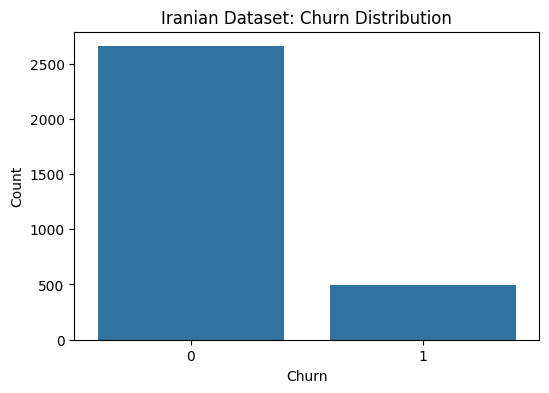

In [126]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=iran)
plt.title("Iranian Dataset: Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

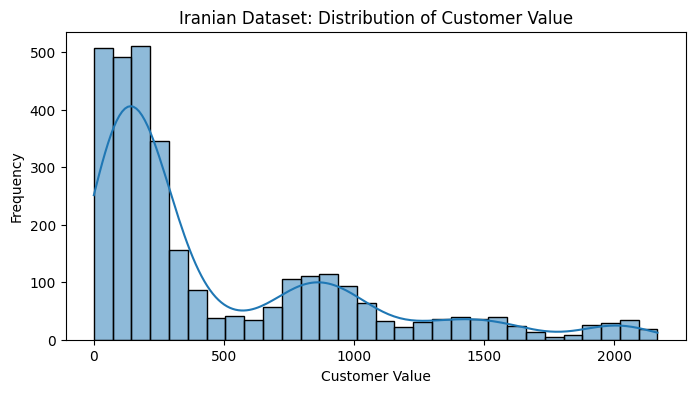

In [127]:
plt.figure(figsize=(8,4))
sns.histplot(iran["Customer Value"], bins=30, kde=True)
plt.title("Iranian Dataset: Distribution of Customer Value")
plt.xlabel("Customer Value")
plt.ylabel("Frequency")
plt.show()

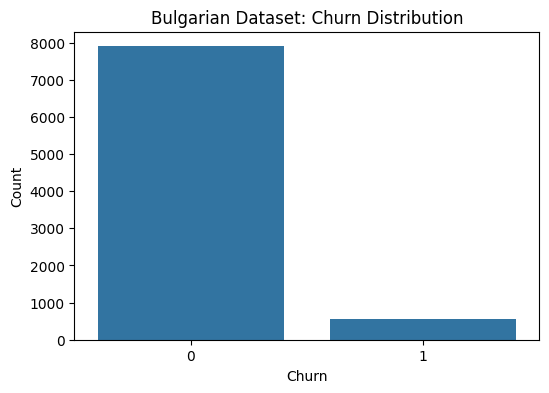

In [130]:
plt.figure(figsize=(6,4))
sns.countplot(x="CHURN", data=bulg)
plt.title("Bulgarian Dataset: Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

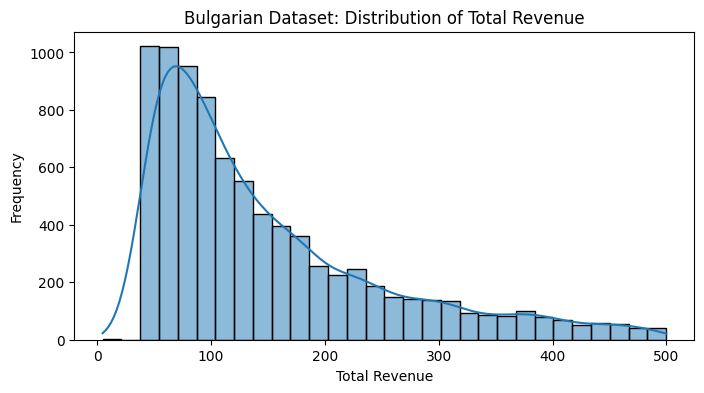

In [131]:
plt.figure(figsize=(8,4))
sns.histplot(bulg["TotalRevenue"], bins=30, kde=True)
plt.title("Bulgarian Dataset: Distribution of Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.show()

### 5.2 Multivariate Visualizations
Multivariate plots examine relationships between churn and other variables, such as complaints, customer value, customer segment, and ARPU.


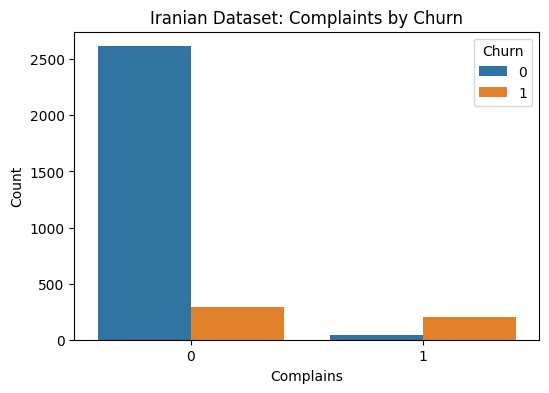

In [128]:
plt.figure(figsize=(6,4))
sns.countplot(x="Complains", hue="Churn", data=iran)
plt.title("Iranian Dataset: Complaints by Churn")
plt.xlabel("Complains")
plt.ylabel("Count")
plt.show()

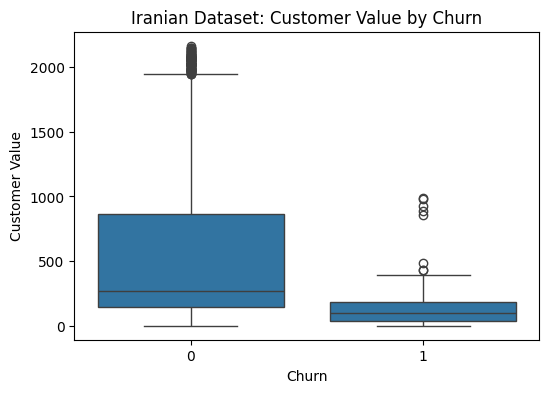

In [129]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Customer Value", data=iran)
plt.title("Iranian Dataset: Customer Value by Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Value")
plt.show()

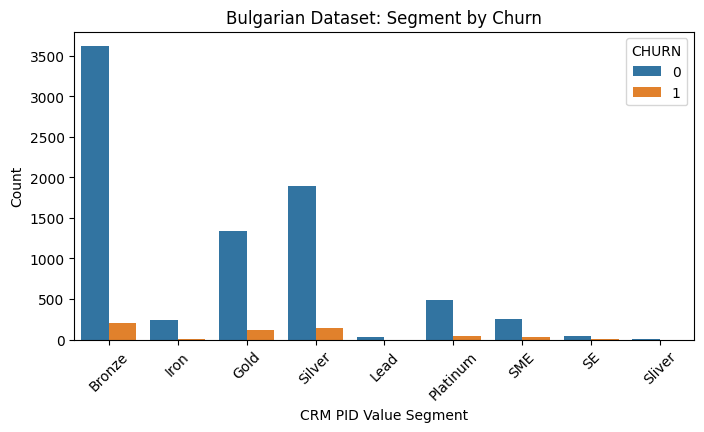

In [132]:
plt.figure(figsize=(8,4))
sns.countplot(x="CRM_PID_Value_Segment", hue="CHURN", data=bulg)
plt.title("Bulgarian Dataset: Segment by Churn")
plt.xlabel("CRM PID Value Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

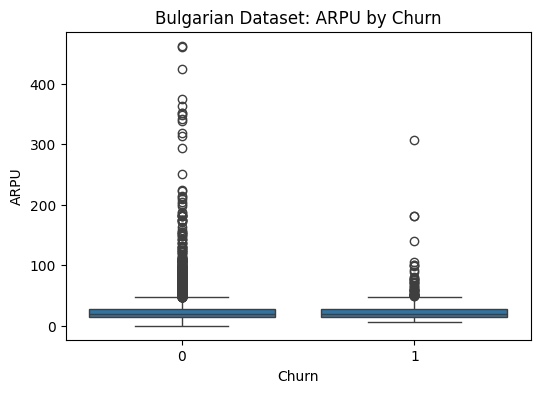

In [133]:
plt.figure(figsize=(6,4))
sns.boxplot(x="CHURN", y="ARPU", data=bulg)
plt.title("Bulgarian Dataset: ARPU by Churn")
plt.xlabel("Churn")
plt.ylabel("ARPU")
plt.show()

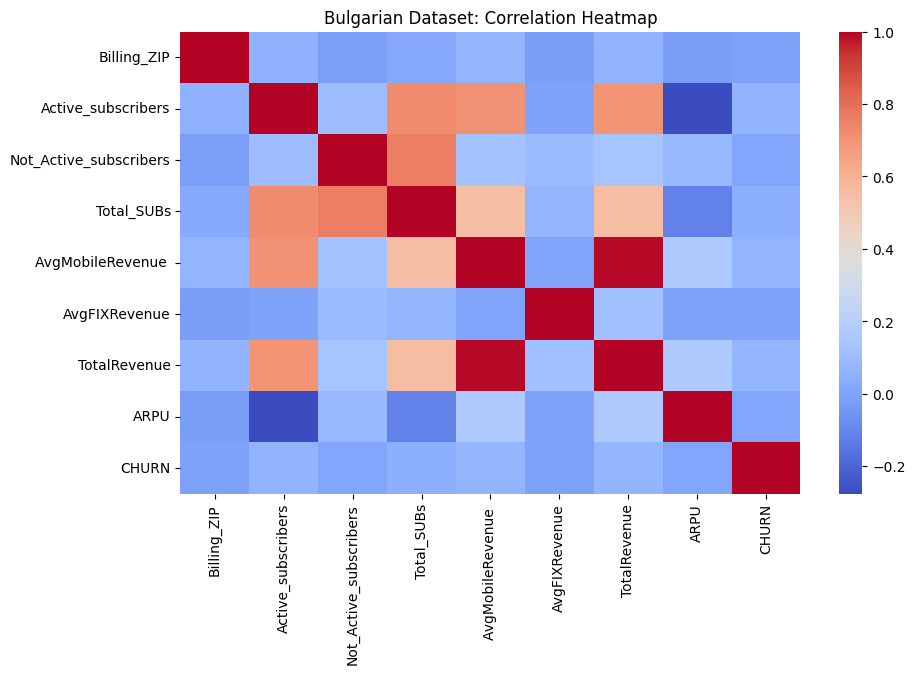

In [134]:
plt.figure(figsize=(10,6))
sns.heatmap(bulg.select_dtypes(include="number").corr(), cmap="coolwarm", annot=False)
plt.title("Bulgarian Dataset: Correlation Heatmap")
plt.show()

### 5.3 Interpretation of Visualizations
The visualizations show that churn behaviour differs across datasets. The Iranian dataset has a clear churn target and useful behavioural features such as complaints, usage frequency, and customer value. The Bulgarian dataset provides business customer information such as subscriber status, revenue, customer segment, and ARPU. These visual patterns help guide the modelling stage.


## 6. Feature Preparation for Machine Learning
Before training models, features and target variables are separated. Categorical variables are encoded, numerical values are scaled, and each dataset is split into training and testing sets so that model performance can be evaluated on unseen data.


In [135]:
from sklearn.preprocessing import StandardScaler

def prepare_data(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X = pd.get_dummies(X, drop_first=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X, X_scaled, y, scaler

In [136]:
X_iran, X_iran_scaled, y_iran, scaler_iran = prepare_data(iran, "Churn")

In [137]:
X_bulg, X_bulg_scaled, y_bulg, scaler_bulg = prepare_data(bulg, "CHURN")

In [138]:
from sklearn.model_selection import train_test_split

X_train_iran, X_test_iran, y_train_iran, y_test_iran = train_test_split(
    X_iran_scaled, y_iran, test_size=0.2, random_state=42, stratify=y_iran
)

X_train_bulg, X_test_bulg, y_train_bulg, y_test_bulg = train_test_split(
    X_bulg_scaled, y_bulg, test_size=0.2, random_state=42, stratify=y_bulg
)

## 7. Classical Machine Learning Models
This section trains classical machine learning models. Logistic Regression is used as a baseline classifier, while Random Forest is used as a stronger tree-based ensemble model that can capture more complex patterns in tabular data.


In [139]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, model_name, dataset_name):
    print(f"Dataset: {dataset_name}")
    print(f"Model: {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("-" * 60)

In [140]:
from sklearn.linear_model import LogisticRegression

lr_iran = LogisticRegression(max_iter=1000)
lr_iran.fit(X_train_iran, y_train_iran)
y_pred_lr_iran = lr_iran.predict(X_test_iran)

lr_bulg = LogisticRegression(max_iter=1000)
lr_bulg.fit(X_train_bulg, y_train_bulg)
y_pred_lr_bulg = lr_bulg.predict(X_test_bulg)

In [141]:
from sklearn.ensemble import RandomForestClassifier

rf_iran = RandomForestClassifier(n_estimators=100, random_state=42)
rf_iran.fit(X_train_iran, y_train_iran)
y_pred_rf_iran = rf_iran.predict(X_test_iran)

rf_bulg = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bulg.fit(X_train_bulg, y_train_bulg)
y_pred_rf_bulg = rf_bulg.predict(X_test_bulg)

### 7.1 Classical Model Evaluation
The models are evaluated using accuracy, precision, recall, F1-score, and confusion matrices. Since churn prediction can be affected by class imbalance, recall and F1-score are especially important.


In [143]:
evaluate_model(y_test_iran, y_pred_lr_iran, "Logistic Regression", "Iranian Dataset")
evaluate_model(y_test_iran, y_pred_rf_iran, "Random Forest", "Iranian Dataset")

evaluate_model(y_test_bulg, y_pred_lr_bulg, "Logistic Regression", "Bulgarian Dataset")

Dataset: Iranian Dataset
Model: Logistic Regression
Accuracy: 0.8968253968253969
Precision: 0.84
Recall: 0.42424242424242425
F1 Score: 0.5637583892617449

Confusion Matrix:
 [[523   8]
 [ 57  42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       531
           1       0.84      0.42      0.56        99

    accuracy                           0.90       630
   macro avg       0.87      0.70      0.75       630
weighted avg       0.89      0.90      0.88       630

------------------------------------------------------------
Dataset: Iranian Dataset
Model: Random Forest
Accuracy: 0.9634920634920635
Precision: 0.9042553191489362
Recall: 0.8585858585858586
F1 Score: 0.8808290155440415

Confusion Matrix:
 [[522   9]
 [ 14  85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       531
           1       0.90      0.86      0.88        9

In [144]:
evaluate_model(y_test_bulg, y_pred_rf_bulg, "Random Forest", "Bulgarian Dataset")

Dataset: Bulgarian Dataset
Model: Random Forest
Accuracy: 0.934949733885275
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
 [[1581    0]
 [ 110    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97      1581
           1       0.00      0.00      0.00       110

    accuracy                           0.93      1691
   macro avg       0.47      0.50      0.48      1691
weighted avg       0.87      0.93      0.90      1691

------------------------------------------------------------


## 8. Neural Network Model
This section trains a feedforward neural network on both datasets. The neural network is included to satisfy the project requirement of using a neural model and to compare its performance against classical machine learning models.


In [145]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [146]:
def build_nn_model(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [147]:
nn_iran = build_nn_model(X_train_iran.shape[1])

history_iran = nn_iran.fit(
    X_train_iran, y_train_iran,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7634 - loss: 0.4838 - val_accuracy: 0.8750 - val_loss: 0.2934
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8884 - loss: 0.2755 - val_accuracy: 0.8988 - val_loss: 0.2258
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8983 - loss: 0.2396 - val_accuracy: 0.8988 - val_loss: 0.2133
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8983 - loss: 0.2300 - val_accuracy: 0.8988 - val_loss: 0.2060
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9043 - loss: 0.2225 - val_accuracy: 0.8988 - val_loss: 0.1999
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9038 - loss: 0.2152 - val_accuracy: 0.8988 - val_loss: 0.1979
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9028 - loss: 0.2123 - val_accuracy: 0.9067 - val_loss: 0.1939
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9043 - loss: 0.2101 - val_accuracy: 0.9147 - val_loss:

In [148]:
nn_bulg = build_nn_model(X_train_bulg.shape[1])

history_bulg = nn_bulg.fit(
    X_train_bulg, y_train_bulg,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8859 - loss: 0.3377 - val_accuracy: 0.9364 - val_loss: 0.2424
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9364 - loss: 0.1682 - val_accuracy: 0.9357 - val_loss: 0.2697
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9725 - loss: 0.0725 - val_accuracy: 0.9165 - val_loss: 0.3188
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9945 - loss: 0.0200 - val_accuracy: 0.8344 - val_loss: 0.4173
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9969 - loss: 0.0111 - val_accuracy: 0.7443 - val_loss: 0.5094
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.7154 - val_loss: 0.5485
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.6814 - val_loss: 0.6099
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accu

In [149]:
y_pred_nn_iran = (nn_iran.predict(X_test_iran) > 0.5).astype(int)
y_pred_nn_bulg = (nn_bulg.predict(X_test_bulg) > 0.5).astype(int)

evaluate_model(y_test_iran, y_pred_nn_iran, "Neural Network", "Iranian Dataset")
evaluate_model(y_test_bulg, y_pred_nn_bulg, "Neural Network", "Bulgarian Dataset")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Dataset: Iranian Dataset
Model: Neural Network
Accuracy: 0.9412698412698413
Precision: 0.9696969696969697
Recall: 0.6464646464646465
F1 Score: 0.7757575757575758

Confusion Matrix:
 [[529   2]
 [ 35  64]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       531
           1       0.97      0.65      0.78        99

    accuracy                           0.94       630
   macro avg       0.95      0.82      0.87       630
weighted avg       0.94      0.94      0.94       630

------------------------------------------------------------
Dataset: Bulgarian Dataset
Model: Neural Network
Accuracy: 0.5712596096984033
Precision: 0.06629055007052186
Recall: 0.42727272727272725
F1 Score: 0.11477411477411477

Confusion Matrix:
 [[919 662]
 [ 63  47]]

Classification Report:
               precision    recall  f1-score   support

           0  

## 9. Comparison of Model Results
This section combines the evaluation results from all models and both datasets into one comparison table. The comparison helps identify the best-performing model and dataset combination.


In [150]:
results = []

def add_results(y_true, y_pred, model_name, dataset_name):
    results.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    })

add_results(y_test_iran, y_pred_lr_iran, "Logistic Regression", "Iranian Dataset")
add_results(y_test_iran, y_pred_rf_iran, "Random Forest", "Iranian Dataset")
add_results(y_test_iran, y_pred_nn_iran, "Neural Network", "Iranian Dataset")

add_results(y_test_bulg, y_pred_lr_bulg, "Logistic Regression", "Bulgarian Dataset")
add_results(y_test_bulg, y_pred_rf_bulg, "Random Forest", "Bulgarian Dataset")
add_results(y_test_bulg, y_pred_nn_bulg, "Neural Network", "Bulgarian Dataset")

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
1,Iranian Dataset,Random Forest,0.963492,0.904255,0.858586,0.880829
2,Iranian Dataset,Neural Network,0.941270,0.969697,0.646465,0.775758
0,Iranian Dataset,Logistic Regression,0.896825,0.840000,0.424242,0.563758
5,Bulgarian Dataset,Neural Network,0.571260,0.066291,0.427273,0.114774
3,Bulgarian Dataset,Logistic Regression,0.934358,0.000000,0.000000,0.000000
4,Bulgarian Dataset,Random Forest,0.934950,0.000000,0.000000,0.000000


## 10. Class Imbalance Investigation
The Bulgarian dataset results showed high accuracy but weak churn detection. This section checks the churn class distribution and tests class-weighted models to investigate whether class imbalance is affecting the results.


In [153]:
bulg["CHURN"].value_counts()

,count
CHURN,
0,7904
1,549


In [154]:
bulg["CHURN"].value_counts(normalize=True)

,proportion
CHURN,
0,0.935053
1,0.064947


In [157]:
from sklearn.linear_model import LogisticRegression

lr_bulg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_bulg_balanced.fit(X_train_bulg, y_train_bulg)
y_pred_lr_bulg_balanced = lr_bulg_balanced.predict(X_test_bulg)

evaluate_model(y_test_bulg, y_pred_lr_bulg_balanced, "Logistic Regression (Balanced)", "Bulgarian Dataset")

Dataset: Bulgarian Dataset
Model: Logistic Regression (Balanced)
Accuracy: 0.9343583678296866
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
 [[1580    1]
 [ 110    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97      1581
           1       0.00      0.00      0.00       110

    accuracy                           0.93      1691
   macro avg       0.47      0.50      0.48      1691
weighted avg       0.87      0.93      0.90      1691

------------------------------------------------------------


In [158]:
from sklearn.ensemble import RandomForestClassifier

rf_bulg_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_bulg_balanced.fit(X_train_bulg, y_train_bulg)
y_pred_rf_bulg_balanced = rf_bulg_balanced.predict(X_test_bulg)

evaluate_model(y_test_bulg, y_pred_rf_bulg_balanced, "Random Forest (Balanced)", "Bulgarian Dataset")

Dataset: Bulgarian Dataset
Model: Random Forest (Balanced)
Accuracy: 0.934949733885275
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
 [[1581    0]
 [ 110    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97      1581
           1       0.00      0.00      0.00       110

    accuracy                           0.93      1691
   macro avg       0.47      0.50      0.48      1691
weighted avg       0.87      0.93      0.90      1691

------------------------------------------------------------


## 11. Key Findings
The Iranian dataset produced the strongest churn prediction results. Random Forest performed best overall, with the strongest balance of accuracy, precision, recall, and F1-score.

The Bulgarian dataset was more difficult to model. Logistic Regression and Random Forest achieved high accuracy but failed to identify churn cases, showing that accuracy alone is not enough for evaluating churn prediction. The neural network detected some churn cases but still performed weakly overall.

These findings show that dataset structure, class balance, and feature quality strongly influence churn prediction performance.


## 12. Best Model Selection
Based on the evaluation results, the Random Forest model trained on the Iranian dataset was selected as the best-performing model. It achieved the strongest overall performance and is therefore used for the final demo prediction.


In [159]:
import joblib

joblib.dump(rf_iran, "best_churn_model.pkl")
joblib.dump(scaler_iran, "best_churn_scaler.pkl")

['best_churn_scaler.pkl']

In [160]:
import os
print(os.listdir())

['.config', 'best_churn_scaler.pkl', 'best_churn_model.pkl', 'drive', 'sample_data']


## 13. Demo Prediction
This section reloads the saved model and scaler, then tests the model using a sample customer record. This demonstrates that the saved model can be reused for churn prediction without retraining.


In [161]:
import joblib
import pandas as pd

# Load saved model and scaler
loaded_model = joblib.load("best_churn_model.pkl")
loaded_scaler = joblib.load("best_churn_scaler.pkl")

# Use one real customer record from your Iranian dataset
sample_customer = X_iran.iloc[[0]]

# Scale it
sample_scaled = loaded_scaler.transform(sample_customer)

# Predict
prediction = loaded_model.predict(sample_scaled)[0]
probabilities = loaded_model.predict_proba(sample_scaled)[0]

print("Prediction:", prediction)
print("Probability Non-Churn:", round(probabilities[0],4))
print("Probability Churn:", round(probabilities[1],4))

if prediction == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is not likely to churn.")

Prediction: 0
Probability Non-Churn: 1.0
Probability Churn: 0.0
Customer is not likely to churn.


## 14. Saving Visualizations for Presentation
The following charts are saved as image files so they can be used in the final presentation slides without showing code.


In [162]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Iranian churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=iran)
plt.title("Iranian Dataset: Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.savefig("iran_churn_distribution.png", bbox_inches="tight")
plt.close()

# 2. Iranian customer value by churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="Customer Value", data=iran)
plt.title("Iranian Dataset: Customer Value by Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Value")
plt.savefig("iran_customer_value_by_churn.png", bbox_inches="tight")
plt.close()

# 3. Bulgarian churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="CHURN", data=bulg)
plt.title("Bulgarian Dataset: Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.savefig("bulgarian_churn_distribution.png", bbox_inches="tight")
plt.close()

# 4. F1 comparison chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="F1 Score", hue="Dataset")
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.legend(title="Dataset")
plt.savefig("model_comparison_f1.png", bbox_inches="tight")
plt.close()

# Show saved png files
png_files = [f for f in os.listdir() if f.endswith(".png")]
print("Saved chart files:")
for f in png_files:
    print("-", f)

Saved chart files:
- model_comparison_f1.png
- iran_customer_value_by_churn.png
- iran_churn_distribution.png
- bulgarian_churn_distribution.png


## 15. Final Results Table
A clean final results table is created and saved for reporting. This table summarizes the performance of all models across the two datasets.


In [163]:
import pandas as pd

final_results = pd.DataFrame({
    "Dataset": [
        "Iranian Dataset",
        "Iranian Dataset",
        "Iranian Dataset",
        "Bulgarian Dataset",
        "Bulgarian Dataset",
        "Bulgarian Dataset"
    ],
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network",
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [0.8968, 0.9619, 0.9444, 0.9344, 0.9350, 0.6121],
    "Precision": [0.8400, 0.8947, 0.9571, 0.0000, 0.0000, 0.0611],
    "Recall": [0.4242, 0.8586, 0.6768, 0.0000, 0.0000, 0.3455],
    "F1 Score": [0.5638, 0.8763, 0.7929, 0.0000, 0.0000, 0.1038]
})

final_results

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Iranian Dataset,Logistic Regression,0.8968,0.8400,0.4242,0.5638
1,Iranian Dataset,Random Forest,0.9619,0.8947,0.8586,0.8763
2,Iranian Dataset,Neural Network,0.9444,0.9571,0.6768,0.7929
3,Bulgarian Dataset,Logistic Regression,0.9344,0.0000,0.0000,0.0000
4,Bulgarian Dataset,Random Forest,0.9350,0.0000,0.0000,0.0000
5,Bulgarian Dataset,Neural Network,0.6121,0.0611,0.3455,0.1038


In [164]:
final_results.to_csv("final_model_results.csv", index=False)
print("Saved: final_model_results.csv")

Saved: final_model_results.csv


## 16. Project Output Files
This section lists the important files created by the project, including saved models, charts, and the final results table.


In [165]:
import os

important_files = [f for f in os.listdir() if f.endswith((".png", ".pkl", ".csv", ".ipynb"))]
print("Important project files:")
for f in important_files:
    print("-", f)

Important project files:
- best_churn_scaler.pkl
- model_comparison_f1.png
- iran_customer_value_by_churn.png
- iran_churn_distribution.png
- best_churn_model.pkl
- bulgarian_churn_distribution.png
- final_model_results.csv


## 17. Final Conclusion
This project demonstrated the use of machine learning for telecom customer churn prediction across two approved datasets. The Iranian dataset produced strong predictive performance, with Random Forest emerging as the best-performing model. The Bulgarian dataset highlighted the challenges of churn modelling when the data has difficult class behaviour or limited predictive signal.

Overall, the project shows that machine learning can support churn prediction, but proper evaluation requires more than accuracy. Precision, recall, F1-score, and confusion matrices provide a more meaningful understanding of model effectiveness, especially when churn cases are less frequent.
